# T5 ETF 策略逆向还原与严格回测

研究对象：截图中的 `T5_15D2P_60I1_5S`。本笔记先尽量复现截图，再逐层去掉理想化假设，回答两个问题：

1. 截图中的高收益是否可以由一套明确规则复现？
2. 对于低操作频率的个人账户，这个策略是否值得沿用？

本研究不是投资建议，也不是自动下单系统。数据截至 2026-07-08；研究池只有六只已知 ETF，存在明显的事后选池与存活偏差。

## tl;dr

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.t5_research import (
    ETF_SYMBOLS,
    INDEX_SETS,
    SimulationConfig,
    StrategyConfig,
    asset_field_matrix,
    build_target_weights,
    load_research_data,
    performance_metrics,
    price_matrices,
    rolling_return_stats,
    run_variant,
)

DATA_START = "2023-01-01"
BACKTEST_START = "2023-09-01"
BACKTEST_END = "2026-07-08"
ONE_WAY_COST = 0.001

frames, manifest = load_research_data(DATA_START, BACKTEST_END, ROOT / "data" / "cache")
asset_open, asset_close, index_close = price_matrices(frames)
asset_high = asset_field_matrix(frames, "high")
asset_low = asset_field_matrix(frames, "low")
asset_twap_proxy = (asset_open + asset_high + asset_low + asset_close) / 4

base_strategy = StrategyConfig()
target, momentum, gate = build_target_weights(asset_close, index_close, base_strategy)

proxy_bt, proxy_metrics, _, _ = run_variant(
    asset_open, asset_close, index_close, base_strategy,
    SimulationConfig(execution="next_close", transaction_cost=0.0,
                     stop_mode="exact_daily_loss_cap"),
    BACKTEST_START, BACKTEST_END,
)
strict_bt, strict_metrics, _, _ = run_variant(
    asset_open, asset_close, index_close, base_strategy,
    SimulationConfig(execution="next_open", transaction_cost=ONE_WAY_COST,
                     stop_mode="none"),
    BACKTEST_START, BACKTEST_END,
)
twap_bt, twap_metrics, _, _ = run_variant(
    asset_open, asset_close, index_close, base_strategy,
    SimulationConfig(execution="next_twap_proxy", transaction_cost=ONE_WAY_COST,
                     stop_mode="none"),
    BACKTEST_START, BACKTEST_END,
    asset_execution_price=asset_twap_proxy,
)

headline = pd.DataFrame([
    {"版本": "截图近似复现（次日收盘/无成本/理想5%止损）", **proxy_metrics},
    {"版本": "严格基线（次日开盘/10bp单边/无理想止损）", **strict_metrics},
    {"版本": "成交区间代理（次日OHLC4/10bp/无理想止损）", **twap_metrics},
]).set_index("版本")

headline_view = headline[["ending_equity", "cagr", "max_drawdown", "sharpe",
                          "calmar", "trade_days_per_year", "average_exposure"]].copy()
display(Markdown(
    "**结论：策略1值得继续研究，但不能直接采用截图成绩。** "
    "六 ETF 短样本中，严格基线仍达到约 3.23 倍终值、约 21% 最大回撤，"
    "平均每年约 32 个发生调仓的交易日；真正的问题不是 45% 回撤，而是"
    "事后选池、样本短和理想化 5% 止损。下一版应保留 2P 与 60I1，重写 5S。"
))
display(headline_view.style.format({
    "ending_equity": "{:.2f}x", "cagr": "{:.1%}", "max_drawdown": "{:.1%}",
    "sharpe": "{:.2f}", "calmar": "{:.2f}", "trade_days_per_year": "{:.1f}",
    "average_exposure": "{:.1%}",
}))

**结论：策略1值得继续研究，但不能直接采用截图成绩。** 六 ETF 短样本中，严格基线仍达到约 3.23 倍终值、约 21% 最大回撤，平均每年约 32 个发生调仓的交易日；真正的问题不是 45% 回撤，而是事后选池、样本短和理想化 5% 止损。下一版应保留 2P 与 60I1，重写 5S。

,ending_equity,cagr,max_drawdown,sharpe,calmar,trade_days_per_year,average_exposure
版本,,,,,,,
截图近似复现（次日收盘/无成本/理想5%止损）,4.68x,76.3%,-17.7%,1.98,4.31,35.6,67.9%
严格基线（次日开盘/10bp单边/无理想止损）,3.23x,53.8%,-21.3%,1.42,2.53,32.0,67.9%
成交区间代理（次日OHLC4/10bp/无理想止损）,3.40x,56.7%,-18.3%,1.87,3.10,32.0,67.9%


## Context & Methods

### 逆向规则

- **T5**：主题/趋势 ETF 横截面动量，持有前两名，各 50%。
- **15D**：使用 `close[t] / close[t-15] - 1` 排名。
- **2P**：新候选的 15 日收益必须比当前最弱持仓高至少 2 个百分点才替换。
- **60I1**：上证指数、深证成指、创业板指、科创50 中，至少一个 60 日动量为正才允许持仓。
- **5S**：截图描述为组合级 5% hard stop，但没有公开可执行细节。因此分成“理想复现”和“严格基线”，不把理想止损当成可交易事实。

动量本身有长期研究基础，但不等于任意短窗口和特定 ETF 池都有效。经典参考：[Jegadeesh & Titman (1993)](https://onlinelibrary.wiley.com/doi/10.1111/j.1540-6261.1993.tb04702.x)；[Moskowitz, Ooi & Pedersen (2012)](https://w4.stern.nyu.edu/facdir/lpederse/papers/TimeSeriesMomentum.pdf)。

### Key Assumptions

| 项目 | 严格基线 | 截图近似复现 |
|---|---|---|
| 信号可用时间 | 收盘后 | 收盘后 |
| 成交时间 | 下一交易日开盘 | 下一交易日收盘 |
| 单边摩擦成本 | 10bp | 0 |
| 5% 止损 | 不假装可精确成交 | 单日组合收益低于 -5% 时精确截断到 -5%，并清仓 |
| 分红/拆分 | 腾讯前复权日线 | 同左 |
| 做空/杠杆 | 无 | 无 |

严格基线故意不使用难以验证的止损价格。OHLC4 仅作为分批成交/TWAP 的粗代理，不代表真实逐笔成交。

## Data

In [2]:
display(Markdown("### 数据清单"))
display(manifest)

snapshot_date = pd.Timestamp("2026-07-08")
snapshot = pd.DataFrame({
    "ETF代码": list(ETF_SYMBOLS),
    "15D动量_本地": [momentum.loc[snapshot_date, code] for code in ETF_SYMBOLS],
    "截图值": [0.268, 0.143, -0.009, -0.051, -0.125, -0.161],
}).set_index("ETF代码")
snapshot["差值"] = snapshot["15D动量_本地"] - snapshot["截图值"]
display(Markdown("### 2026-07-08 截图交叉核对"))
display(snapshot.style.format("{:.1%}"))

display(Markdown(
    "前五只与截图基本逐项吻合。561380 在窗口内发生份额拆分，前复权供应商处理差异使其偏差稍大；"
    "这也是为什么本文不把小数点后一位的完全一致当作真实性证明。"
))

### 数据清单

,label,symbol,name,first_date,last_date,rows
0,159516,sz159516,半导体设备ETF国泰,2023-07-27,2026-07-08,713
1,513120,sh513120,港股创新药ETF广发,2023-01-03,2026-07-08,849
2,159206,sz159206,卫星ETF永赢,2025-03-14,2026-07-08,320
3,562500,sh562500,机器人ETF华夏,2023-01-03,2026-07-08,849
4,515880,sh515880,通信ETF国泰,2023-01-03,2026-07-08,849
5,561380,sh561380,电网设备ETF国泰,2024-12-23,2026-07-08,372
6,上证指数,sh000001,上证指数,2023-01-03,2026-07-08,849
7,深证成指,sz399001,深证成指,2023-01-03,2026-07-08,849
8,创业板指,sz399006,创业板指,2023-01-03,2026-07-08,849
9,科创50,sh000688,科创50,2023-01-03,2026-07-08,849


### 2026-07-08 截图交叉核对

,15D动量_本地,截图值,差值
ETF代码,,,
159516,26.8%,26.8%,0.0%
513120,14.3%,14.3%,-0.0%
159206,-0.9%,-0.9%,0.0%
562500,-5.1%,-5.1%,0.0%
515880,-12.5%,-12.5%,0.0%
561380,-14.9%,-16.1%,1.2%


前五只与截图基本逐项吻合。561380 在窗口内发生份额拆分，前复权供应商处理差异使其偏差稍大；这也是为什么本文不把小数点后一位的完全一致当作真实性证明。

## Results

### 1. 截图成绩可以近似复现，但依赖理想化止损

In [3]:
sample_windows = {
    "扩展压力样本": "2023-09-01",
    "主优化样本": "2024-09-24",
    "完整六只短样本": "2025-03-14",
}
reported = {
    "扩展压力样本": {"ending_equity": 4.6794, "max_drawdown": -0.198, "sharpe": 2.05},
    "主优化样本": {"ending_equity": 5.2908, "max_drawdown": -0.151, "sharpe": 2.91},
    "完整六只短样本": {"ending_equity": 3.9632, "max_drawdown": -0.150, "sharpe": 3.28},
}

rows = []
for sample, start in sample_windows.items():
    bt, metrics, _, _ = run_variant(
        asset_open, asset_close, index_close, base_strategy,
        SimulationConfig(execution="next_close", transaction_cost=0.0,
                         stop_mode="exact_daily_loss_cap"),
        start, BACKTEST_END,
    )
    rows.append({"样本": sample, "版本": "截图报告", **reported[sample]})
    rows.append({"样本": sample, "版本": "本地近似复现", **metrics})

reconstruction = pd.DataFrame(rows)
display(reconstruction[["样本", "版本", "ending_equity", "max_drawdown", "sharpe"]]
        .style.format({"ending_equity": "{:.2f}x", "max_drawdown": "{:.1%}", "sharpe": "{:.2f}"}))

stop_dates = proxy_bt.index[proxy_bt["stop_triggered"]].strftime("%Y-%m-%d").tolist()
display(Markdown(
    f"扩展样本中共有 **{len(stop_dates)}** 次收益被精确截断为 -5%："
    + "、".join(stop_dates)
    + "。这个处理显著贡献了复现效果，却不是用日线数据可以证明能够成交的规则。"
))

,样本,版本,ending_equity,max_drawdown,sharpe
0,扩展压力样本,截图报告,4.68x,-19.8%,2.05
1,扩展压力样本,本地近似复现,4.68x,-17.7%,1.98
2,主优化样本,截图报告,5.29x,-15.1%,2.91
3,主优化样本,本地近似复现,5.36x,-16.3%,2.82
4,完整六只短样本,截图报告,3.96x,-15.0%,3.28
5,完整六只短样本,本地近似复现,4.24x,-13.9%,3.33


扩展样本中共有 **7** 次收益被精确截断为 -5%：2024-10-08、2024-10-10、2025-02-27、2025-04-03、2025-09-03、2026-01-23、2026-07-01。这个处理显著贡献了复现效果，却不是用日线数据可以证明能够成交的规则。

### 2. 去掉理想化假设后，收益下降，但风险收益比仍有吸引力

In [4]:
strict_rows = []
for sample, start in sample_windows.items():
    for label, sim, exec_price in [
        ("次日开盘/10bp/无止损", SimulationConfig("next_open", ONE_WAY_COST, "none"), None),
        ("次日OHLC4/10bp/无止损", SimulationConfig("next_twap_proxy", ONE_WAY_COST, "none"), asset_twap_proxy),
        ("OHLC低点保守止损/10bp", SimulationConfig("next_twap_proxy", ONE_WAY_COST, "ohlc_stop"), asset_twap_proxy),
    ]:
        bt, metrics, _, _ = run_variant(
            asset_open, asset_close, index_close, base_strategy, sim, start, BACKTEST_END,
            asset_low=asset_low, asset_execution_price=exec_price,
        )
        strict_rows.append({"样本": sample, "版本": label, **metrics})

strict_table = pd.DataFrame(strict_rows)
display(strict_table[["样本", "版本", "ending_equity", "cagr", "max_drawdown", "sharpe",
                      "calmar", "trade_days_per_year", "stop_count"]]
        .style.format({"ending_equity": "{:.2f}x", "cagr": "{:.1%}",
                       "max_drawdown": "{:.1%}", "sharpe": "{:.2f}",
                       "calmar": "{:.2f}", "trade_days_per_year": "{:.1f}"}))

display(Markdown(
    "OHLC 低点止损把两只 ETF 的日内最低价视为同时发生，因此是偏保守的下界，不是主估计。"
    "严格基线没有达到截图的夸张收益，但在这段短样本里仍明显高于‘3年翻倍、45%回撤’的低效率目标。"
))

,样本,版本,ending_equity,cagr,max_drawdown,sharpe,calmar,trade_days_per_year,stop_count
0,扩展压力样本,次日开盘/10bp/无止损,3.23x,53.8%,-21.3%,1.42,2.53,32.0,0
1,扩展压力样本,次日OHLC4/10bp/无止损,3.40x,56.7%,-18.3%,1.87,3.10,32.0,0
2,扩展压力样本,OHLC低点保守止损/10bp,2.44x,38.9%,-21.4%,1.34,1.81,42.2,21
3,主优化样本,次日开盘/10bp/无止损,3.79x,118.5%,-21.3%,2.05,5.57,42.8,0
4,主优化样本,次日OHLC4/10bp/无止损,3.94x,123.3%,-17.8%,2.71,6.94,42.8,0
5,主优化样本,OHLC低点保守止损/10bp,2.83x,84.1%,-21.4%,1.99,3.93,59.2,21
6,完整六只短样本,次日开盘/10bp/无止损,3.28x,155.7%,-15.1%,2.48,10.30,41.9,0
7,完整六只短样本,次日OHLC4/10bp/无止损,3.32x,158.1%,-14.9%,3.28,10.63,41.9,0
8,完整六只短样本,OHLC低点保守止损/10bp,2.68x,118.0%,-17.7%,2.58,6.66,58.5,14


OHLC 低点止损把两只 ETF 的日内最低价视为同时发生，因此是偏保守的下界，不是主估计。严格基线没有达到截图的夸张收益，但在这段短样本里仍明显高于‘3年翻倍、45%回撤’的低效率目标。

### 3. 2P 降低交易噪声；60I1 用部分收益换取回撤控制

In [5]:
ablation_specs = [
    ("15D排名", StrategyConfig(replacement_buffer=0.0), False),
    ("15D + 2P", StrategyConfig(replacement_buffer=0.02), False),
    ("15D + 2P + 60I1", StrategyConfig(replacement_buffer=0.02), True),
]
ablation_rows = []
for label, strategy, use_filter in ablation_specs:
    bt, metrics, _, _ = run_variant(
        asset_open, asset_close, index_close, strategy,
        SimulationConfig("next_open", ONE_WAY_COST, "none"),
        BACKTEST_START, BACKTEST_END, use_index_filter=use_filter,
    )
    ablation_rows.append({"规则": label, **metrics})

ablation = pd.DataFrame(ablation_rows).set_index("规则")
display(ablation[["ending_equity", "cagr", "max_drawdown", "calmar",
                  "trade_days_per_year", "average_exposure"]]
        .style.format({"ending_equity": "{:.2f}x", "cagr": "{:.1%}",
                       "max_drawdown": "{:.1%}", "calmar": "{:.2f}",
                       "trade_days_per_year": "{:.1f}", "average_exposure": "{:.1%}"}))

,ending_equity,cagr,max_drawdown,calmar,trade_days_per_year,average_exposure
规则,,,,,,
15D排名,3.56x,59.5%,-31.9%,1.86,60.2,100.0%
15D + 2P,4.03x,66.9%,-31.6%,2.12,30.1,100.0%
15D + 2P + 60I1,3.23x,53.8%,-21.3%,2.53,32.0,67.9%


### 4. 参数邻域：不以单一最优点为依据

In [6]:
grid_rows = []
for momentum_window in [10, 15, 20, 30]:
    for replacement_buffer in [0.00, 0.02, 0.04]:
        for index_window in [60]:
            strategy = StrategyConfig(
                momentum_window=momentum_window,
                replacement_buffer=replacement_buffer,
                index_window=index_window,
            )
            bt, metrics, _, _ = run_variant(
                asset_open, asset_close, index_close, strategy,
                SimulationConfig("next_open", ONE_WAY_COST, "none"),
                BACKTEST_START, BACKTEST_END,
            )
            grid_rows.append({
                "momentum_window": momentum_window,
                "replacement_buffer": replacement_buffer,
                "index_window": index_window,
                **metrics,
            })

parameter_grid = pd.DataFrame(grid_rows)
parameter_summary = parameter_grid.groupby(["momentum_window", "replacement_buffer"]).agg(
    median_cagr=("cagr", "median"),
    worst_drawdown=("max_drawdown", "min"),
    median_calmar=("calmar", "median"),
    median_trade_days=("trade_days_per_year", "median"),
).reset_index()

pass_efficiency = (
    (parameter_grid["ending_equity"] >= 3.0)
    & (parameter_grid["max_drawdown"] >= -0.30)
)
display(Markdown(
    f"12 组核心邻域参数中，**{pass_efficiency.mean():.0%}** 同时满足本段样本终值至少 3 倍且最大回撤不超过 30%。"
    "该比例只用于看局部稳定性，不是未来成功概率。"
))
display(parameter_summary.style.format({
    "replacement_buffer": "{:.0%}", "median_cagr": "{:.1%}",
    "worst_drawdown": "{:.1%}", "median_calmar": "{:.2f}",
    "median_trade_days": "{:.1f}",
}))

gate_rows = []
for index_window in [40, 60, 80]:
    strategy = StrategyConfig(index_window=index_window)
    bt, metrics, _, _ = run_variant(
        asset_open, asset_close, index_close, strategy,
        SimulationConfig("next_open", ONE_WAY_COST, "none"),
        BACKTEST_START, BACKTEST_END,
    )
    gate_rows.append({"index_window": index_window, **metrics})
gate_check = pd.DataFrame(gate_rows).set_index("index_window")
display(Markdown("**市场状态窗口单独检查：**"))
display(gate_check[["ending_equity", "cagr", "max_drawdown", "calmar"]].style.format({
    "ending_equity": "{:.2f}x", "cagr": "{:.1%}",
    "max_drawdown": "{:.1%}", "calmar": "{:.2f}",
}))

12 组核心邻域参数中，**92%** 同时满足本段样本终值至少 3 倍且最大回撤不超过 30%。该比例只用于看局部稳定性，不是未来成功概率。

,momentum_window,replacement_buffer,median_cagr,worst_drawdown,median_calmar,median_trade_days
0,10,0%,57.6%,-19.0%,3.03,62.1
1,10,2%,57.7%,-18.4%,3.15,40.4
2,10,4%,57.7%,-19.9%,2.90,32.3
3,15,0%,51.1%,-21.9%,2.34,51.1
4,15,2%,53.8%,-21.3%,2.53,32.0
5,15,4%,62.1%,-19.5%,3.18,24.6
6,20,0%,57.5%,-20.5%,2.80,43.3
7,20,2%,63.9%,-20.2%,3.16,29.0
8,20,4%,58.1%,-19.9%,2.93,23.5
9,30,0%,46.7%,-25.5%,1.83,37.5


**市场状态窗口单独检查：**

,ending_equity,cagr,max_drawdown,calmar
index_window,,,,
40,2.57x,41.5%,-21.6%,1.93
60,3.23x,53.8%,-21.3%,2.53
80,3.30x,55.0%,-20.2%,2.73


### 5. 权益曲线、回撤和参数热图

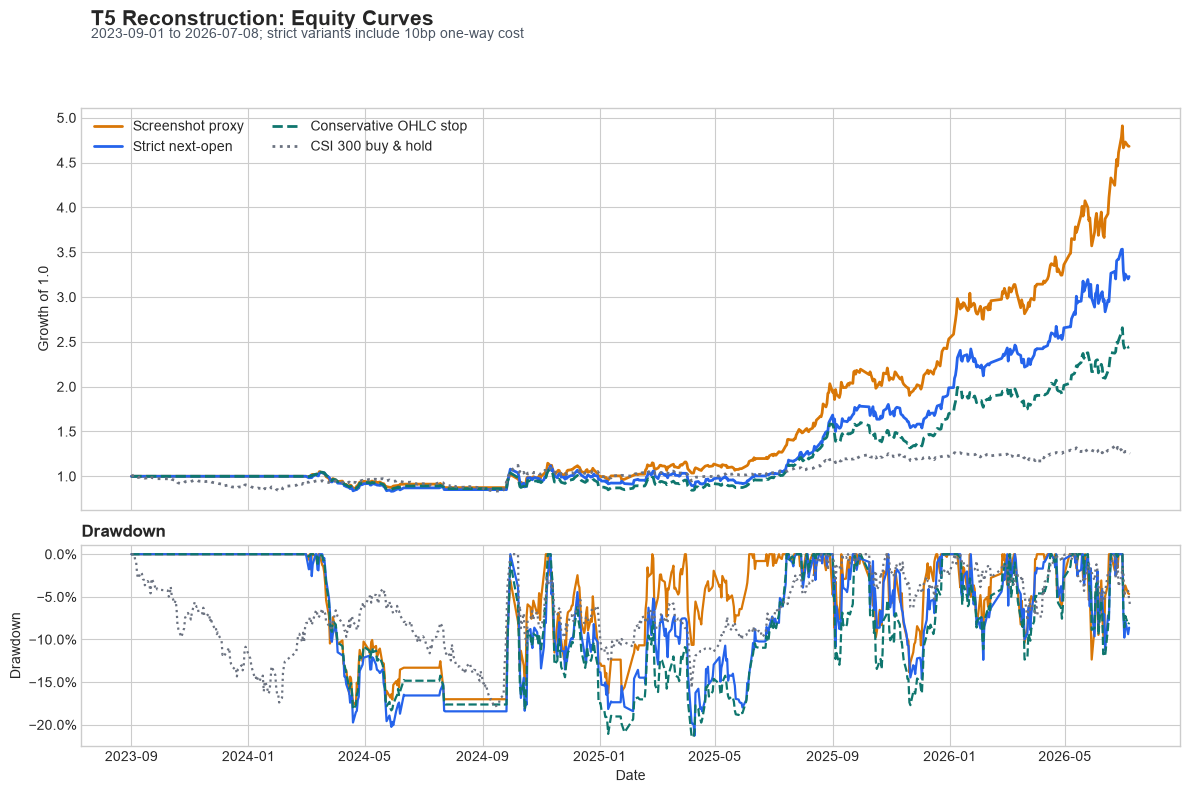

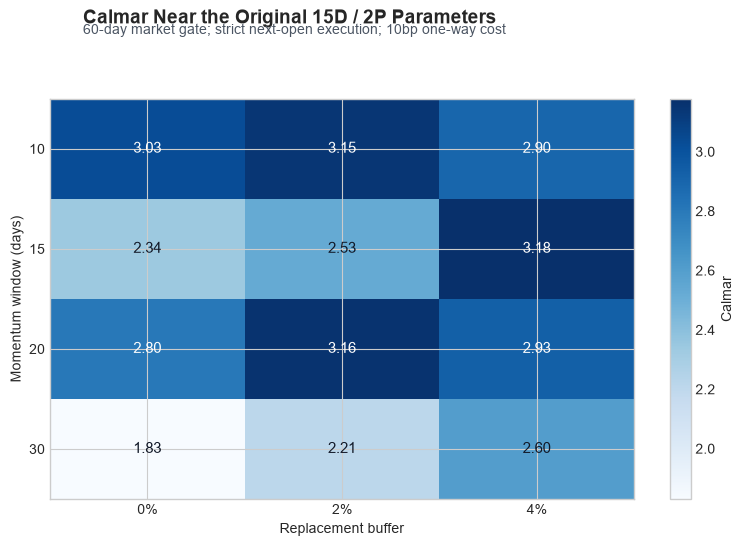

In [7]:
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

benchmark_close = index_close["沪深300"].loc[BACKTEST_START:BACKTEST_END].dropna()
benchmark_equity = benchmark_close / benchmark_close.iloc[0]
benchmark_dd = benchmark_equity / benchmark_equity.cummax() - 1

conservative_bt, conservative_metrics, _, _ = run_variant(
    asset_open, asset_close, index_close, base_strategy,
    SimulationConfig("next_twap_proxy", ONE_WAY_COST, "ohlc_stop"),
    BACKTEST_START, BACKTEST_END,
    asset_low=asset_low, asset_execution_price=asset_twap_proxy,
)

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
curves = [
    (proxy_bt["equity"], "Screenshot proxy", "#D97706", "-"),
    (strict_bt["equity"], "Strict next-open", "#2563EB", "-"),
    (conservative_bt["equity"], "Conservative OHLC stop", "#0F766E", "--"),
    (benchmark_equity, "CSI 300 buy & hold", "#6B7280", ":"),
]
for series, label, color, linestyle in curves:
    axes[0].plot(series.index, series.values, label=label, color=color,
                 linestyle=linestyle, linewidth=2)
    dd = series / series.cummax() - 1
    axes[1].plot(dd.index, dd.values, label=label, color=color,
                 linestyle=linestyle, linewidth=1.6)
fig.suptitle("T5 Reconstruction: Equity Curves", x=0.08, y=0.985,
             ha="left", fontsize=15, weight="bold")
fig.text(0.08, 0.95,
         "2023-09-01 to 2026-07-08; strict variants include 10bp one-way cost",
         ha="left", color="#4B5563", fontsize=10)
axes[0].set_ylabel("Growth of 1.0")
axes[0].legend(frameon=False, ncol=2)
axes[1].set_title("Drawdown", loc="left", fontsize=12, weight="bold")
axes[1].set_ylabel("Drawdown")
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
axes[1].set_xlabel("Date")
fig.tight_layout(rect=[0, 0, 1, 0.925])
equity_chart = OUTPUT_DIR / "t5_equity_drawdown.png"
fig.savefig(equity_chart, dpi=180, bbox_inches="tight")
plt.show()

heat = parameter_summary.pivot(index="momentum_window", columns="replacement_buffer",
                               values="median_calmar")
fig, ax = plt.subplots(figsize=(8, 5.5))
image = ax.imshow(heat.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(heat.columns)), [f"{value:.0%}" for value in heat.columns])
ax.set_yticks(range(len(heat.index)), heat.index)
ax.set_xlabel("Replacement buffer")
ax.set_ylabel("Momentum window (days)")
fig.suptitle("Calmar Near the Original 15D / 2P Parameters", x=0.11, y=0.985,
             ha="left", fontsize=14, weight="bold")
fig.text(0.11, 0.94,
         "60-day market gate; strict next-open execution; 10bp one-way cost",
         ha="left", color="#4B5563", fontsize=10)
for row in range(heat.shape[0]):
    for col in range(heat.shape[1]):
        value = heat.iloc[row, col]
        ax.text(col, row, f"{value:.2f}", ha="center", va="center",
                color="white" if value > heat.values.mean() else "#111827", fontsize=11)
fig.colorbar(image, ax=ax, label="Calmar")
fig.tight_layout(rect=[0, 0, 1, 0.91])
parameter_chart = OUTPUT_DIR / "t5_parameter_sensitivity.png"
fig.savefig(parameter_chart, dpi=180, bbox_inches="tight")
plt.show()

headline.reset_index().to_csv(OUTPUT_DIR / "summary_metrics.csv", index=False, encoding="utf-8-sig")
parameter_grid.to_csv(OUTPUT_DIR / "parameter_grid.csv", index=False, encoding="utf-8-sig")

### 6. 滚动结果与低频操作

In [8]:
rolling = rolling_return_stats(strict_bt, 252)
rolling_view = pd.Series(rolling, name="严格基线滚动252交易日").to_frame()
display(rolling_view.style.format({"严格基线滚动252交易日": "{:.1%}"}, na_rep="—"))

trade_days = strict_bt.index[strict_bt["turnover"] > 0.05]
trade_gap = pd.Series(trade_days).diff().dt.days.dropna()
display(Markdown(
    f"严格基线共有 **{len(trade_days)}** 个发生显著换仓的交易日，约 "
    f"**{strict_metrics['trade_days_per_year']:.1f} 天/年**；调仓日之间的中位自然日间隔约 "
    f"**{trade_gap.median():.0f} 天**。这符合‘每天不想频繁操作’，但仍需收盘后每日检查信号。"
))

,严格基线滚动252交易日
count,43400.0%
worst,-14.9%
median,46.6%
best,252.1%
positive_share,79.7%


严格基线共有 **87** 个发生显著换仓的交易日，约 **32.0 天/年**；调仓日之间的中位自然日间隔约 **6 天**。这符合‘每天不想频繁操作’，但仍需收盘后每日检查信号。

## Takeaways

1. **策略骨架基本还原。** 六只 ETF 的 15 日排名与截图高度吻合；`上证/深成/创业板/科创50` 的 60 日过滤也最能解释样本结果。
2. **截图成绩不是严格可交易成绩。** 近似复现必须依赖无成本、次日收盘成交，以及把多次日损失精确锁死在 -5% 的理想机制。
3. **策略1仍值得延展。** 严格基线在当前短样本中约 3.23 倍、约 21% 最大回撤，明显优于“45% 回撤换 3 年翻倍”。但这不是样本外承诺。
4. **保留 2P。** 它显著减少无效替换与交易频率；这是目前最可信、也最符合个人执行约束的模块。
5. **保留 60I1，但把它视为风险预算开关。** 它牺牲一部分绝对收益，换来更低回撤与更高 Calmar。
6. **重写 5S。** 下一步应比较可执行的收盘止损、波动率目标仓位与组合级回撤降档，不能继续使用“精确 -5% 成交”。
7. **当前还不能上线。** 最大缺口是只有六只、而且很可能事后挑选的 ETF 池。下一轮必须建立按当时可得信息形成的动态主题池，并做 walk-forward/留出期验证。

### 下一轮研究门槛

- 主门槛：滚动三年净值中位数 ≥ 3 倍，最差滚动三年仍为正；最大回撤目标 ≤ 30%，压力上限 45%。
- 执行门槛：单边成本 10–20bp 后仍成立；平均显著调仓日 ≤ 40 天/年。
- 稳健门槛：参数邻域有效，而不是单点最优；动态 ETF 池与留出期不崩。
- 否决条件：若严格滚动三年只能约 2 倍，却仍需承受接近 45% 回撤，则直接放弃。